# DeepXDE Solution for 2D Navier Stokes

The Navier–Stokes equations are partial differential equations which describe the motion of viscous fluid substances.

Momentum Equations for $\,\, U \,\,$ and $\,\, V \,\,$ as well as the _continuity equation_ :

\begin{align}
    \frac{\partial U}{\partial t} + \Bigg( U \frac{\partial U}{\partial x} + V \frac{\partial U}{\partial y} \Bigg) \, &= \, - \frac{1}{\rho} \frac{\partial P}{\partial x} + \nu \Bigg(\frac{\partial^2 U}{\partial x^2} + \frac{\partial^2 U}{\partial y^2} \Bigg)\\[3em]

    \frac{\partial V}{\partial t} + \Bigg( U \frac{\partial V}{\partial x} + V \frac{\partial V}{\partial y} \Bigg) \, &= \, - \frac{1}{\rho} \frac{\partial P}{\partial y} + \nu \Bigg(\frac{\partial^2 V}{\partial x^2} + \frac{\partial^2 V}{\partial y^2} \Bigg) \\[3em]

    \frac{\partial U}{\partial x} + \frac{\partial V}{\partial y} \, &= \, 0
\end{align}

where 

* $\, U \,$ and $\, V \,$ are the U and V velocity components, respectively,

* $\frac{\partial U}{\partial t}$ and $\frac{\partial V}{\partial t}$ is the time rate of change of U and V,

* $\frac{\partial U}{\partial x}$ and $\frac{\partial V}{\partial x}$ are the spatial rates of change of U and V in the $x$-direction,

* $\frac{\partial U}{\partial y}$ and $\frac{\partial V}{\partial y}$ are the spatial rates of change of U and V in the $y$-direction,

* $P$ is the pressure,

* $\rho$ is the fluid density,

* $\nu$ is the kinematic viscosity of the fluid.


We will focus on the _steady state_ solution which implies that the change of anything with respect to time is zero, i.e. $\frac{\partial U}{\partial t}$ and $\frac{\partial V}{\partial t}$ are neglected. The _continuity equation_ $(3)$ ensures that mass is preserved.

For a _similar_ problem see DeepXDE docu on [Kovasznay flow](https://deepxde.readthedocs.io/en/latest/demos/pinn_forward/Kovasznay.flow.html).

In [1]:
#pip install tensorflow

In [2]:
import tensorflow as tf
import deepxde as dde
import numpy as np
import matplotlib.pyplot as plt

Using backend: pytorch
Other supported backends: tensorflow.compat.v1, tensorflow, jax, paddle.
paddle supports more examples now and is recommended.


## Set Geometry

In [3]:
# Initialize parameters
rho = 1             # fluid density
mu = 1              # dynamic viscosity; nu=mu/rho
u_in = 1            # flow inlet

Next, set the boundaries of the computational domain. Consider length $L$ and width $D$ which span a $2$-dimensional space as shown below. The origin of the $xy$-coordinate system will be centered in the DxL space and the domains D and L will range from $-D/2$ to $D/2$ and $-L/2$ to $L/2$, respectively.

In [4]:
# Set domain boundaries
D = 1               # Width boundary of the DxL space
L = 2               # Length boundary of the DxL space

<center>
    <img src="images/LDSpace.png" width=800 style="background-color:grey"/>
</center>

In [5]:
# Define rectangle as shown in the figure above
geom = dde.geometry.Rectangle(xmin=[-L/2, -D/2],        # lower left corner of the rectangle
                              xmax=[L/2,   D/2])        # upper right corner of the rectangle

## Set Boundary Conditions

In [6]:
# Check whether point X is on wall boundary (walls = horizontal lines at D/2 and -D/2)
def boundary_wall(X, on_boundary):
    #print("X", X)
    #print("on_boundary", on_boundary)

    # Check whether X is on the wall boundary and return its location; 
    # X[0] refers to x, X[1] refers to y
    on_wall = np.logical_and(np.logical_or(np.isclose(X[1], -D/2, rtol=1e-05, atol=1e-08),      # check whether the point is located on the lower wall (-D/2) --> y-value (X[1]) should be close to -D/2
                                           np.isclose(X[1],  D/2, rtol=1e-05, atol=1e-08)),     # check whether the point is located on the upper wall (D/2)  --> y-value (X[1]) should be close to D/2
                             on_boundary)
    # Return boolean
    return on_wall


# Check whether point X is on inlet boundary (inlet = vertical line at -L/2)
def boundary_inlet(X, on_boundary):
    on_inlet = np.logical_and(np.isclose(X[0], -L/2, rtol=1e-05, atol=1e-08),                   # inlet --> x-value (X[0]) should be close to -L/2
                              on_boundary)
    # Return boolean
    return on_inlet


# Check whether point X is on outlet boundary (outlet = vertical line at L/2)
def boundary_outlet(X, on_boundary):
    on_outlet = np.logical_and(np.isclose(X[0], L/2, rtol=1e-05, atol=1e-08),                   # outlet --> x-value (X[0]) should be close to L/2
                               on_boundary)
    # Return boolean    
    return on_outlet

In [7]:
# Specify where the boundary points are located; baundary_* are boolean
bc_wall_u = dde.DirichletBC(geom, lambda X:0., boundary_wall, component=0)          # component=0 refers to u; if boundary_wall=True the point is on the wall boundary and will have a value of 0.
bc_wall_v = dde.DirichletBC(geom, lambda X:0., boundary_wall, component=1)          # component=1 refers to v

bc_inlet_u = dde.DirichletBC(geom, lambda X:u_in, boundary_inlet, component=0)
bc_inlet_v = dde.DirichletBC(geom, lambda X:0.  , boundary_inlet, component=1)

bc_outlet_v = dde.DirichletBC(geom, lambda X:0. , boundary_outlet, component=1)
bc_outlet_p = dde.DirichletBC(geom, lambda X:0. , boundary_outlet, component=2)     # component=1 refers to pressure

## Define the Network and PDE

The DeepXDE documentation on gradients can be found [here](https://deepxde.readthedocs.io/en/latest/modules/deepxde.gradients.html).

In [8]:
# PDE function where X contains the independent values (x, y) and Y contains the dependent values (u, v, p)
def pde(X, Y):
    # First Order Derivatives
    ## i \in [0, 1, 2] = [U, V, P]; j \in [0, 1] = [x, y]
    du_x = dde.grad.jacobian(Y, X, i=0, j=0)            # i=0 refers to velocity U, j=0 refers to x
    du_y = dde.grad.jacobian(Y, X, i=0, j=1)            # j=1 refers to y
    dv_x = dde.grad.jacobian(Y, X, i=1, j=0)            # i=1 refers to velocity V
    dv_y = dde.grad.jacobian(Y, X, i=1, j=1)
    dp_x = dde.grad.jacobian(Y, X, i=2, j=0)            # i=2 refers to P
    dp_y = dde.grad.jacobian(Y, X, i=2, j=1)
    
    # Second Order Derivatives
    du_xx = dde.grad.hessian(Y, X, component=0, i=0, j=0)
    du_yy = dde.grad.hessian(Y, X, component=0, i=1, j=1)
    dv_xx = dde.grad.hessian(Y, X, component=1, i=0, j=0)
    dv_yy = dde.grad.hessian(Y, X, component=1, i=1, j=1)
    
    # Calculate PDE residuals based on rearranged PDEs from Eq. (1)-(3)
    ## Recall: we neglect dU/dt bc we are looking at the steady state
    ## Y[:, 0:1] = U;  Y[:, 1:2] = V
    pde_u    = Y[:, 0:1]*du_x + Y[:, 1:2]*du_y + 1/rho*dp_x - (mu/rho) * (du_xx + du_yy)    # Eq. (1) - Momentum Equation U; recall nu=mu/rho
    pde_v    = Y[:, 0:1]*dv_x + Y[:, 1:2]*dv_y + 1/rho*dp_y - (mu/rho) * (dv_xx + dv_yy)    # Eq. (2) - Momentum Equation V
    pde_cont = du_x + dv_y                                                                  # Eq. (3) - Continuity Equation
    
    return [pde_u, pde_v, pde_cont]

In [9]:
data = dde.data.PDE(geom,
                    pde,
                    [bc_wall_u, bc_wall_v, bc_inlet_u, bc_inlet_v, bc_outlet_p, bc_outlet_v],       # inlet, outlet and wall boundaries
                    num_domain = 2000,
                    num_boundary = 200,
                    num_test = 200)

c:\Users\kunst\AppData\Local\anaconda3\envs\torchenv\Lib\site-packages\skopt\space\space.py:111: UserWarning: Dimension (0.0, 1.0) was inferred to Real(low=0.0, high=1.0, prior='uniform', transform='identity'). In upcoming versions of scikit-optimize, it will be inferred to <TypeError: Real.__init__() got an unexpected keyword argument 'tranform'>. See the documentation of the check_dimension function for the upcoming API.
  warnings.warn(
c:\Users\kunst\AppData\Local\anaconda3\envs\torchenv\Lib\site-packages\skopt\space\space.py:111: UserWarning: Dimension (0.0, 1.0) was inferred to Real(low=0.0, high=1.0, prior='uniform', transform='identity'). In upcoming versions of scikit-optimize, it will be inferred to <TypeError: Real.__init__() got an unexpected keyword argument 'tranform'>. See the documentation of the check_dimension function for the upcoming API.
  warnings.warn(
c:\Users\kunst\AppData\Local\anaconda3\envs\torchenv\Lib\site-packages\skopt\space\space.py:111: UserWarning: Di

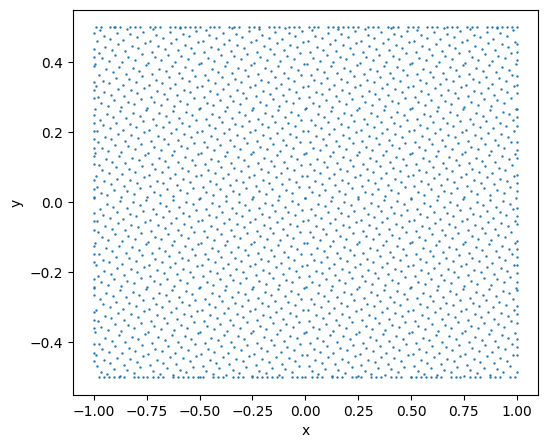

In [10]:
plt.figure(figsize=(6,5))
plt.scatter(data.train_x_all[:, 0],         # x 
            data.train_x_all[:, 1],         # y
            s=0.5)
plt.xlabel("x")
plt.ylabel("y")
plt.show()

In [11]:
net = dde.maps.FNN([2] + 5*[64] + [3] ,     # 2 input nodes (x, y), 5 hidden layers with 64 nodes each, 3 output nodes (u, v, p)
                   "tanh",                  # activation function
                   "Glorot uniform")        # random initialization of weights but with mean 0

## Train the model

In [12]:
model = dde.Model(data, net)
model.compile("adam", lr=1e-3)      # lr = learning rate

Compiling model...
'compile' took 0.308993 s



In [13]:
# Note training may take about 15 minutes
losshistory, train_state = model.train(epochs=10000)

Training model...

Step      Train loss                                                                                    Test loss                                                                                     Test metric
0         [7.54e-02, 2.30e-02, 7.09e-03, 8.89e-03, 1.28e-03, 1.31e+00, 1.54e-03, 7.27e-02, 1.50e-03]    [7.73e-02, 2.25e-02, 7.21e-03, 8.89e-03, 1.28e-03, 1.31e+00, 1.54e-03, 7.27e-02, 1.50e-03]    []  
1000      [8.12e-03, 8.73e-04, 8.93e-03, 2.80e-02, 1.55e-02, 3.72e-02, 1.26e-03, 2.40e-03, 3.97e-05]    [7.52e-03, 6.20e-04, 5.19e-03, 2.80e-02, 1.55e-02, 3.72e-02, 1.26e-03, 2.40e-03, 3.97e-05]    []  
2000      [3.51e-03, 3.45e-03, 4.57e-03, 2.17e-02, 1.13e-02, 3.01e-02, 7.47e-04, 1.29e-04, 1.27e-04]    [2.68e-03, 3.34e-03, 2.63e-03, 2.17e-02, 1.13e-02, 3.01e-02, 7.47e-04, 1.29e-04, 1.27e-04]    []  
3000      [4.74e-03, 2.40e-03, 2.99e-03, 1.81e-02, 9.22e-03, 2.56e-02, 1.80e-03, 5.53e-04, 5.75e-05]    [4.05e-03, 2.08e-03, 1.06e-03, 1.81e-02, 9.22e-03, 2.56e-0

In [14]:
# Use the L-BFGS optimizer for post-processing to further enhance the model

# Note execution may take about 5 minutes
dde.optimizers.config.set_LBFGS_options(maxiter=3000)
model.compile("L-BFGS")
losshistory, train_state = model.train()
dde.saveplot(losshistory, train_state, issave=False, isplot=False)

Compiling model...
'compile' took 0.000886 s

Training model...

Step      Train loss                                                                                    Test loss                                                                                     Test metric
10000     [7.47e-04, 3.52e-04, 2.21e-03, 1.48e-02, 5.50e-03, 1.39e-02, 5.54e-03, 5.31e-04, 5.41e-06]    [6.55e-04, 2.35e-04, 8.69e-04, 1.48e-02, 5.50e-03, 1.39e-02, 5.54e-03, 5.31e-04, 5.41e-06]    []  
11000     [5.39e-04, 5.89e-04, 7.09e-04, 6.63e-03, 1.13e-03, 5.03e-03, 1.87e-03, 2.75e-05, 1.20e-06]    [3.57e-04, 2.85e-04, 3.37e-04, 6.63e-03, 1.13e-03, 5.03e-03, 1.87e-03, 2.75e-05, 1.20e-06]    []  
12000     [3.77e-04, 4.08e-04, 5.16e-04, 4.14e-03, 1.01e-03, 3.68e-03, 1.24e-03, 1.72e-05, 5.71e-07]    [2.11e-04, 2.49e-04, 2.12e-04, 4.14e-03, 1.01e-03, 3.68e-03, 1.24e-03, 1.72e-05, 5.71e-07]    []  
13000     [3.89e-04, 2.37e-04, 5.68e-04, 3.40e-03, 7.53e-04, 2.80e-03, 8.31e-04, 2.18e-05, 5.59e-06]    [1.54e-04, 1

## Result evaluation

In [15]:
# Generate some test data for prediction
samples = geom.random_points(500000)
result = model.predict(samples)

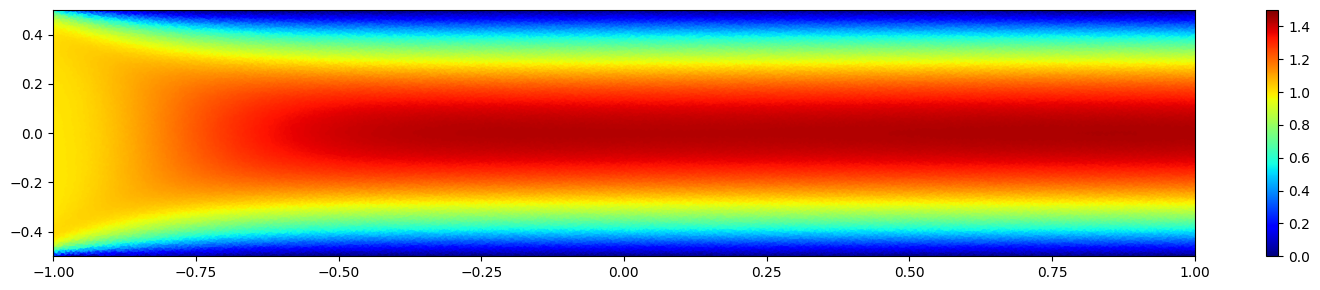

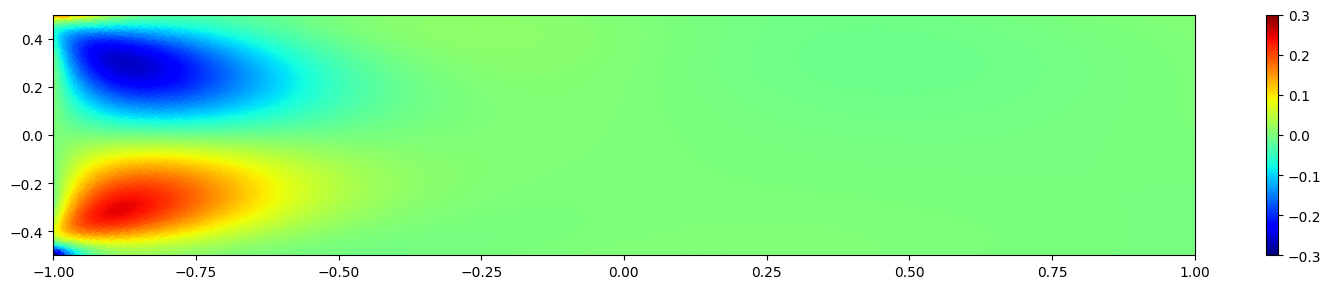

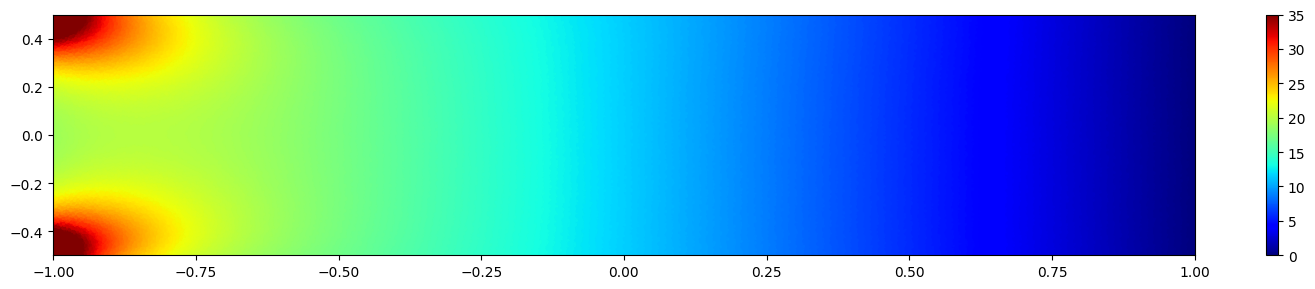

In [19]:
color_legend = [[0, 1.5], 
                [-0.3, 0.3], 
                [0, 35]]

for idx in range(3):                        # 3 plots: idx \in (0, 1, 2) = (u, v, p)
    plt.figure(figsize=(15, 3))
    plt.scatter(samples[:, 0],
                samples[:, 1],
                c = result[:, idx],
                cmap = 'jet',               # color scheme
                s = 2)                      # size of the points (2=small)
    plt.colorbar()
    plt.clim(color_legend[idx])
    plt.xlim((-L/2, L/2))                   # lower and upper domain boundary of L
    plt.ylim((-D/2, D/2))                   # lower and upper domain boundary of D
    plt.tight_layout()
    plt.show()